# Per-Visit Late Fusion Learning Curve

**Goal**: Measure whether decision choice becomes more or less decodable across visits by fitting a separate LOSO late-fusion model on each visit's trials independently.

Each model is trained and evaluated only on the subjects present in that visit — so accuracy reflects how well the multimodal signal predicts choices within that session, with no leakage from other visits.

**Cohort**: 80-subject EEG set with corrected session_mapping.

In [35]:
import sys
sys.path.append('../..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

from src.utils.io import load_features
from src.models.fusion import weighted_late_fusion

TIMEFRAME = 'PRE'
RESULTS_DIR = Path(f'../../data/results/main/late_fusion/fusion_model_results_{TIMEFRAME}')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')

print(f'TIMEFRAME: {TIMEFRAME}')

TIMEFRAME: PRE


## 1. Load Data

In [36]:
feature_data = load_features(f'../../data/features/extracted_features_{TIMEFRAME}.pkl', timeframe=TIMEFRAME)

df = feature_data['merged_df'].copy()
physio_cols   = feature_data['physio_cols']
behavior_cols = feature_data['behavior_cols']
gaze_cols     = feature_data['gaze_cols']

# Restrict to 80-subject EEG set
EEG_ACC_PATH = '../../data/results/main/eeg_integration/fusion_models_eeg_PRE/late_fusion_with_eeg_PRE_subject_accuracies.csv'
eeg_subjects = set(pd.read_csv(EEG_ACC_PATH)['subject_id'])
df = df[df['subject_id'].isin(eeg_subjects)].copy()

# Add visit info from corrected session_mapping
sm = pd.read_csv('../../data/results/session_mapping.csv',
                 dtype={'mmdd': str, 'hhmm': str, 'user_id': str})
sm['subject_id'] = sm['mmdd'] + '_' + sm['hhmm'] + '_' + sm['user_id']
df = df.merge(sm[['subject_id', 'visit_number', 'team', 'user_id']], on='subject_id', how='left')

print(f'Trials: {len(df)}, Subjects: {df["subject_id"].nunique()}')
print('Subjects per visit:')
print(df.groupby('visit_number')['subject_id'].nunique())
print(f'NaN visit: {df["visit_number"].isna().sum()}')

Trials: 9618, Subjects: 80
Subjects per visit:
visit_number
1.0    38
2.0    31
3.0    11
Name: subject_id, dtype: int64
NaN visit: 0


## 2. Per-Visit LOSO Late Fusion

For each visit independently: impute features, run LOSO late fusion (same hyperparameters as the main model), collect per-subject accuracies. This gives three accuracy distributions — one per visit — that are directly comparable because each model only ever sees its own visit's data.

In [37]:
feat_cols = physio_cols + behavior_cols + gaze_cols

def run_visit_loso(visit_df):
    imp = SimpleImputer(strategy='mean')
    X = imp.fit_transform(visit_df[feat_cols])
    y = visit_df['outcome'].values
    subjects = visit_df['subject_id'].values

    X_physio   = X[:, :len(physio_cols)]
    X_behavior = X[:, len(physio_cols):len(physio_cols)+len(behavior_cols)]
    X_gaze     = X[:, len(physio_cols)+len(behavior_cols):]

    results = weighted_late_fusion(
        [X_physio, X_behavior, X_gaze],
        y, subjects,
        modality_names=['Physiology', 'Behavior', 'Gaze'],
        n_estimators=100, max_depth=5,
        min_samples_split=10, min_samples_leaf=5,
        class_weight='balanced', random_state=RANDOM_STATE,
        fusion_method='weighted'
    )
    subj_df = pd.DataFrame([
        {'subject_id': sid, 'accuracy': acc}
        for sid, acc in results['subject_accs'].items()
    ])
    return results, subj_df


visit_results = {}
for visit in [1.0, 2.0, 3.0]:
    vdf = df[df['visit_number'] == visit].copy()
    n_subj = vdf['subject_id'].nunique()
    print(f'Visit {int(visit)}: {n_subj} subjects, {len(vdf)} trials — running LOSO...')
    res, sdf = run_visit_loso(vdf)
    sdf['visit_number'] = int(visit)
    visit_results[visit] = {'summary': res, 'subject_df': sdf}
    print(f'  Accuracy: {res["accuracy_mean"]:.4f} ± {res["accuracy_sem"]:.4f}  '
          f'F1: {res["f1_mean"]:.4f} ± {res["f1_sem"]:.4f}')

Visit 1: 38 subjects, 4597 trials — running LOSO...


Python(23807) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


  Accuracy: 0.7349 ± 0.0174  F1: 0.7314 ± 0.0173
Visit 2: 31 subjects, 3704 trials — running LOSO...
  Accuracy: 0.7408 ± 0.0282  F1: 0.7172 ± 0.0291
Visit 3: 11 subjects, 1317 trials — running LOSO...
  Accuracy: 0.7386 ± 0.0497  F1: 0.7049 ± 0.0500


## 3. Summary Table & Statistical Tests

In [38]:
summary_rows = []
for visit, vr in visit_results.items():
    r = vr['summary']
    summary_rows.append({
        'visit': int(visit),
        'n_subjects': r['n_subjects'],
        'n_trials': r['n_trials'],
        'accuracy_mean': r['accuracy_mean'],
        'accuracy_sem': r['accuracy_sem'],
        'f1_mean': r['f1_mean'],
        'f1_sem': r['f1_sem'],
    })
summary_df = pd.DataFrame(summary_rows).set_index('visit')
print('Per-visit LOSO late fusion results:')
print(summary_df.round(4).to_string())

print('\nOne-sample t-tests vs 0.5 (chance):')
for visit, vr in visit_results.items():
    accs = vr['subject_df']['accuracy'].values
    t, p = stats.ttest_1samp(accs, 0.5)
    print(f'  Visit {int(visit)}: mean={accs.mean():.4f}, t={t:.3f}, p={p:.4f}')

Per-visit LOSO late fusion results:
       n_subjects  n_trials  accuracy_mean  accuracy_sem  f1_mean  f1_sem
visit                                                                    
1              38      4597         0.7349        0.0174   0.7314  0.0173
2              31      3704         0.7408        0.0282   0.7172  0.0291
3              11      1317         0.7386        0.0497   0.7049  0.0500

One-sample t-tests vs 0.5 (chance):
  Visit 1: mean=0.7349, t=13.534, p=0.0000
  Visit 2: mean=0.7408, t=8.553, p=0.0000
  Visit 3: mean=0.7386, t=4.798, p=0.0007


## 4. Plots

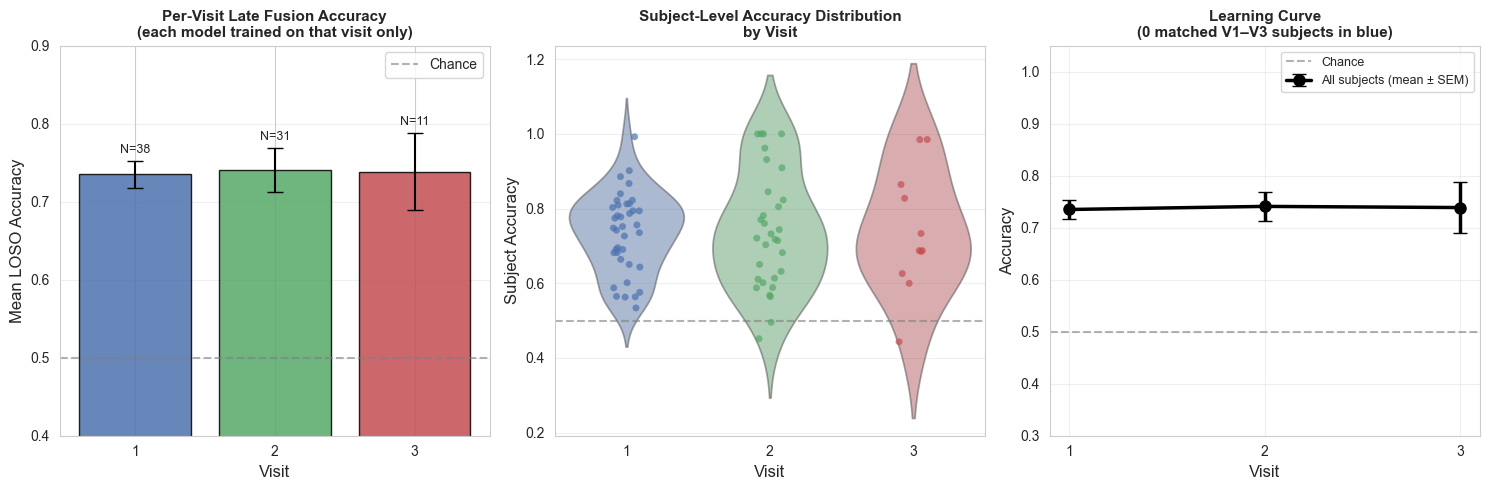

Saved.


In [39]:
visit_colors = {1: '#4C72B0', 2: '#55A868', 3: '#C44E52'}
palette_list = [visit_colors[v] for v in [1, 2, 3]]
all_subj_df = pd.concat([vr['subject_df'] for vr in visit_results.values()], ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Panel A: mean ± SEM per visit
ax = axes[0]
visits = [1, 2, 3]
means  = [visit_results[float(v)]['summary']['accuracy_mean'] for v in visits]
sems   = [visit_results[float(v)]['summary']['accuracy_sem']  for v in visits]
n_subj = [visit_results[float(v)]['summary']['n_subjects']    for v in visits]
ax.bar(visits, means, yerr=sems, capsize=6,
       color=[visit_colors[v] for v in visits], alpha=0.85, edgecolor='black')
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='Chance')
for v, m, s, n in zip(visits, means, sems, n_subj):
    ax.text(v, m + s + 0.01, f'N={n}', ha='center', fontsize=9)
ax.set_xlabel('Visit', fontsize=12)
ax.set_ylabel('Mean LOSO Accuracy', fontsize=12)
ax.set_title('Per-Visit Late Fusion Accuracy\n(each model trained on that visit only)',
             fontsize=11, fontweight='bold')
ax.set_xticks(visits)
ax.set_ylim(0.4, 0.9)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3, axis='y')

# Panel B: per-subject accuracy distributions
ax = axes[1]
sns.violinplot(data=all_subj_df, x='visit_number', y='accuracy',
               palette=palette_list, inner=None, alpha=0.5, ax=ax)
sns.stripplot(data=all_subj_df, x='visit_number', y='accuracy',
              palette=palette_list, size=5, jitter=True, alpha=0.7, ax=ax)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6)
ax.set_xlabel('Visit', fontsize=12)
ax.set_ylabel('Subject Accuracy', fontsize=12)
ax.set_title('Subject-Level Accuracy Distribution\nby Visit', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')

# Panel C: learning curve with matched V1-V2-V3 subjects overlaid
ax = axes[2]
ax.errorbar(visits, means, yerr=sems, marker='o', linewidth=2.5,
            markersize=8, color='black', capsize=5,
            label='All subjects (mean ± SEM)', zorder=5)
ax.axhline(0.5, color='gray', linestyle='--', alpha=0.6, label='Chance')

matched_v1v2v3 = (set(visit_results[1.0]['subject_df']['subject_id']) &
                  set(visit_results[2.0]['subject_df']['subject_id']) &
                  set(visit_results[3.0]['subject_df']['subject_id']))
for sid in matched_v1v2v3:
    pts = []
    for v in [1.0, 2.0, 3.0]:
        row = visit_results[v]['subject_df']
        acc = row[row['subject_id'] == sid]['accuracy'].values
        pts.append(acc[0] if len(acc) else np.nan)
    ax.plot([1, 2, 3], pts, color='steelblue', alpha=0.35, linewidth=1)

ax.set_xlabel('Visit', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title(f'Learning Curve\n({len(matched_v1v2v3)} matched V1–V3 subjects in blue)',
             fontsize=11, fontweight='bold')
ax.set_xticks(visits)
ax.set_ylim(0.3, 1.05)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / f'per_visit_loso_accuracy_{TIMEFRAME}.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved.')

## 5. Save Results

In [40]:
summary_df.to_csv(RESULTS_DIR / f'per_visit_loso_summary_{TIMEFRAME}.csv')
all_subj_df.to_csv(RESULTS_DIR / f'per_visit_loso_subject_accuracies_{TIMEFRAME}.csv', index=False)
print(f'Results saved to {RESULTS_DIR}')
print()
print(summary_df.round(4).to_string())

Results saved to ../../data/results/main/late_fusion/fusion_model_results_PRE

       n_subjects  n_trials  accuracy_mean  accuracy_sem  f1_mean  f1_sem
visit                                                                    
1              38      4597         0.7349        0.0174   0.7314  0.0173
2              31      3704         0.7408        0.0282   0.7172  0.0291
3              11      1317         0.7386        0.0497   0.7049  0.0500
